# 11 - Graph Community Detection

**Problem framing.** When data is relational - a similarity graph over customers, a co-purchase network, a social graph - the natural notion of a cluster is a *community*: a set of nodes densely connected to each other and sparsely connected to the rest. We detect communities with spectral clustering on the graph and judge a partition with Newman modularity, choosing the number of communities by maximising it.

**Assumptions.** The graph is undirected; communities are assortative (more edges within than between); and the graph is connected enough for a spectral embedding. We use a stochastic block model so the planted communities give an honest offline check.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

sys.path.append(str(Path.cwd() / "src"))

from unsup_lab.graphs import (
    best_partition_by_modularity,
    detect_communities,
    make_block_graph,
    modularity,
)

## A graph with planted communities

A stochastic block model with four communities: edges are common within a community and rare between communities. Reordered by community, the adjacency matrix shows the block structure we hope to recover.

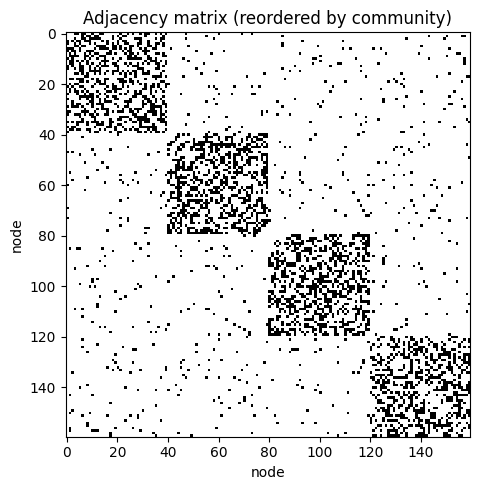

In [2]:
adjacency, planted = make_block_graph(
    sizes=[40, 40, 40, 40], p_in=0.40, p_out=0.03, random_state=11
)

order = np.argsort(planted)
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(adjacency.toarray()[order][:, order], cmap="Greys", interpolation="nearest")
ax.set_title("Adjacency matrix (reordered by community)")
ax.set_xlabel("node")
ax.set_ylabel("node")
plt.tight_layout()
plt.show()

## Choosing the number of communities by modularity

Modularity compares the within-community edge density to what chance would produce. Sweeping the community count and taking the peak is a principled way to choose it - no labels required.

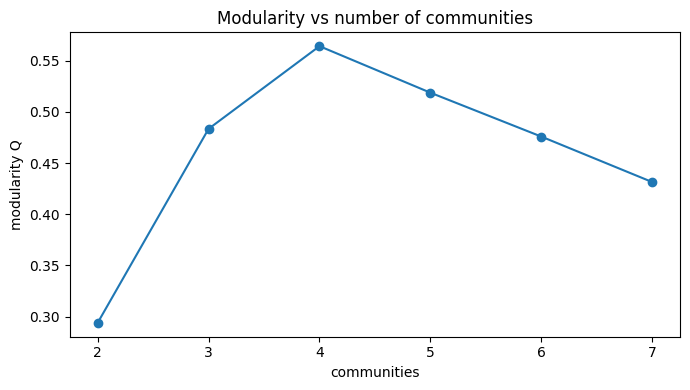

selected communities: 4 (true = 4)
modularity: 0.564
ARI vs planted communities: 1.000


In [3]:
candidates = [2, 3, 4, 5, 6, 7]
curve = [
    detect_communities(adjacency, k, random_state=0).modularity for k in candidates
]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(candidates, curve, marker="o")
ax.set_title("Modularity vs number of communities")
ax.set_xlabel("communities")
ax.set_ylabel("modularity Q")
plt.tight_layout()
plt.show()

best = best_partition_by_modularity(adjacency, candidates, random_state=0)
print(f"selected communities: {best.n_communities} (true = 4)")
print(f"modularity: {best.modularity:.3f}")
print(f"ARI vs planted communities: {adjusted_rand_score(planted, best.labels):.3f}")

## Baseline on a harder graph

When community structure is strong, even naive methods work. The honest test is a weakly-structured graph (within- and between-community densities much closer). Here we compare spectral community detection against a naive baseline that runs KMeans directly on the adjacency rows.

In [4]:
hard_adjacency, hard_planted = make_block_graph(
    sizes=[50, 50, 50], p_in=0.18, p_out=0.08, random_state=5
)

spectral = detect_communities(hard_adjacency, n_communities=3, random_state=0)
naive = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(
    hard_adjacency.toarray()
)

spectral_ari = adjusted_rand_score(hard_planted, spectral.labels)
naive_ari = adjusted_rand_score(hard_planted, naive)
print(f"spectral community detection ARI: {spectral_ari:.3f}")
print(f"KMeans-on-adjacency baseline ARI: {naive_ari:.3f}")
print(f"spectral modularity: {spectral.modularity:.3f}")
print(f"baseline modularity: {modularity(hard_adjacency, naive):.3f}")

spectral community detection ARI: 0.607
KMeans-on-adjacency baseline ARI: 0.214
spectral modularity: 0.210
baseline modularity: 0.137


## Interpretation and limitations

On a clearly-structured graph, modularity peaks at the true number of communities and spectral clustering recovers them almost perfectly. On a weakly-structured graph the spectral embedding still beats running KMeans directly on the adjacency rows, because it uses the global structure in the graph Laplacian rather than raw connectivity vectors.

**Limitations.**

- Modularity has a resolution limit: it can fail to find communities smaller than a scale set by the total number of edges, merging them.
- Spectral clustering needs the number of communities (we choose it by modularity) and is O(n^2)-O(n^3), so very large graphs need scalable methods (Louvain, Leiden, or sparse eigensolvers).
- The stochastic block model assumes assortative, roughly homogeneous communities; real graphs have hubs, overlapping communities and degree heterogeneity that this simple setup ignores.
- A high-modularity partition can still appear in essentially random graphs, so modularity should be sanity-checked against a null model.